In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#1. **Gathering Data**

In [87]:
# Load dataset
df_core = pd.read_csv("mental_health_and_technology_usage_2024.csv")
df_extra = pd.read_csv("ScreenTime vs MentalWellness.csv")

# Menampilkan Preview dataset
print(df_core.head())
print(df_extra.head())

      User_ID  Age  Gender  Technology_Usage_Hours  Social_Media_Usage_Hours  \
0  USER-00001   23  Female                    6.57                      6.00   
1  USER-00002   21    Male                    3.01                      2.57   
2  USER-00003   51    Male                    3.04                      6.14   
3  USER-00004   25  Female                    3.84                      4.48   
4  USER-00005   53    Male                    1.20                      0.56   

   Gaming_Hours  Screen_Time_Hours Mental_Health_Status Stress_Level  \
0          0.68              12.36                 Good          Low   
1          3.74               7.61                 Poor         High   
2          1.26               3.16                 Fair         High   
3          2.59              13.08            Excellent       Medium   
4          0.29              12.63                 Good          Low   

   Sleep_Hours  Physical_Activity_Hours Support_Systems_Access  \
0         8.01      

Fitur utama pada dataset (ScreenTime vs MentalWellness.csv)
- **user_id**: ID unik pada setiap responden
- **age**: Usia pengguna [berguna untuk melihat kelelahan berdasarkan umur]
- **gender**: Jenis kelamin [berguna untuk analisis perbedaan perilaku]
- **occupation**: Jenis pekerjaan [berguna untuk analisis segmentasi antara pelajar vs pekerja]
- **work_mode**: Jenis mode pekerjaan, contoh: remote, hybrid, onsite
- **screen_time_hours**: total waktu layar (jam/hari)
- **work_screen_hours**: total waktu bekerja
- **leisure_screen_hours**: total waktu untuk santai
- **sleep_hours**: total waktu tidur
- **sleep_quality_1_5**: kualitas waktu tidur skala 1-5
- **stress_level_0_10**: tingkatan stres sekala 0-10
- **productivity_0_100**: performa produktivitas skala 0-100
- **exercise_minutes_per_week**: waktu olahraga per minggu
- **social_hours_per_week**: waktu interaksi sosial per minggu
- **mental_wellness_index_0_100**: indeks kesehatan mental skala 0-100

# 2. **Data Assesing**

In [88]:
# Menampilkan beberapa info penting tentang dataset, seperti jumlah baris, kolom, tipe data, dan jumlah nilai yang tidak null.
df_core.info()
df_extra.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   User_ID                   10000 non-null  object 
 1   Age                       10000 non-null  int64  
 2   Gender                    10000 non-null  object 
 3   Technology_Usage_Hours    10000 non-null  float64
 4   Social_Media_Usage_Hours  10000 non-null  float64
 5   Gaming_Hours              10000 non-null  float64
 6   Screen_Time_Hours         10000 non-null  float64
 7   Mental_Health_Status      10000 non-null  object 
 8   Stress_Level              10000 non-null  object 
 9   Sleep_Hours               10000 non-null  float64
 10  Physical_Activity_Hours   10000 non-null  float64
 11  Support_Systems_Access    10000 non-null  object 
 12  Work_Environment_Impact   10000 non-null  object 
 13  Online_Support_Usage      10000 non-null  object 
dtypes: floa

In [89]:
# Menampilkan statistik deskriptif untuk kolom numerik, seperti mean, median, standar deviasi, dan quartiles.
df_core.describe()
df_extra.describe()

,age,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100,Unnamed: 15
count,400.00000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,0.0
mean,29.77750,9.024900,2.183075,6.841825,7.013175,1.397500,8.150500,54.306500,109.810000,7.905000,20.326750,NaN
std,7.46608,2.491058,1.931321,2.220896,0.852421,0.652348,2.094844,15.020054,70.007045,4.909632,20.376793,NaN
min,16.00000,1.000000,0.110000,0.890000,4.640000,1.000000,0.000000,20.600000,0.000000,0.000000,0.000000,NaN
25%,24.00000,7.372500,0.695000,5.460000,6.397500,1.000000,6.900000,43.600000,58.000000,4.575000,3.675000,NaN
50%,30.00000,9.090000,1.455000,6.700000,7.030000,1.000000,8.800000,51.750000,103.000000,7.750000,14.800000,NaN
75%,35.00000,10.495000,3.012500,8.417500,7.640000,2.000000,10.000000,63.000000,157.000000,11.025000,30.650000,NaN
max,60.00000,19.170000,12.040000,13.350000,9.740000,4.000000,10.000000,100.000000,372.000000,23.900000,97.000000,NaN


In [90]:
# Mengecek jumlah nilai yang hilang (null) di setiap kolom untuk mengetahui apakah ada missing values yang perlu diimputasi atau dihapus.
df_core.isnull().sum()
df_extra.isnull().sum()

user_id                          0
age                              0
gender                           0
occupation                       0
work_mode                        0
screen_time_hours                0
work_screen_hours                0
leisure_screen_hours             0
sleep_hours                      0
sleep_quality_1_5                0
stress_level_0_10                0
productivity_0_100               0
exercise_minutes_per_week        0
social_hours_per_week            0
mental_wellness_index_0_100      0
Unnamed: 15                    400
dtype: int64

In [91]:
# Mengecek jumlah baris yang duplikat untuk memastikan tidak ada data yang terduplikasi yang dapat mempengaruhi hasil analisis.
df_core.duplicated().sum()
df_extra.duplicated().sum()

np.int64(0)

In [92]:
df_extra.drop(columns=['Unnamed:_15'], inplace=True, errors='ignore')

#3. **Cleaning Data**

In [93]:
df_core.drop_duplicates(inplace=True)
df_extra.drop_duplicates(inplace=True)

In [94]:
# isi dengan median biar robust
df_core.fillna(df_core.median(numeric_only=True), inplace=True)
df_extra.fillna(df_extra.median(numeric_only=True), inplace=True)

In [95]:
df_core.rename(columns={
    'screen_time_hours': 'screen_time',
    'sleep_hours': 'sleep_hours',
    'stress_level': 'stress_level'
}, inplace=True)

df_extra.rename(columns={
    'screen_time_hours': 'screen_time',
    'sleep_hours': 'sleep_hours',
    'sleep_quality_1_5': 'sleep_quality',
    'stress_level_0_10': 'stress_level',
    'productivity_0_100': 'productivity',
    'mental_wellness_index_0_100': 'wellness_index'
}, inplace=True)

In [96]:
print(df_core.columns.tolist())
print(df_extra.columns.tolist())

['User_ID', 'Age', 'Gender', 'Technology_Usage_Hours', 'Social_Media_Usage_Hours', 'Gaming_Hours', 'Screen_Time_Hours', 'Mental_Health_Status', 'Stress_Level', 'Sleep_Hours', 'Physical_Activity_Hours', 'Support_Systems_Access', 'Work_Environment_Impact', 'Online_Support_Usage']
['user_id', 'age', 'gender', 'occupation', 'work_mode', 'screen_time', 'work_screen_hours', 'leisure_screen_hours', 'sleep_hours', 'sleep_quality', 'stress_level', 'productivity', 'exercise_minutes_per_week', 'social_hours_per_week', 'wellness_index', 'Unnamed: 15']


In [ ]:
df_core.rename(columns={
    'Screen_Time_Hours': 'screen_time',
    'Sleep_Hours': 'sleep_hours',
    'Stress_Level': 'stress_level',
    'Mental_Health_Status': 'mental_health_status'
}, inplace=True)

df_core = df_core[[
    'screen_time',
    'sleep_hours',
    'stress_level',
    'mental_health_status'
]]

df_extra = df_extra[[
    'screen_time',
    'sleep_hours',
    'stress_level',
    'productivity',
    'wellness_index'
]]

KeyError: "None of [Index(['screen_time', 'sleep_hours', 'stress_level', 'mental_health_status'], dtype='object')] are in the [columns]"

In [ ]:
# rename biar sama
df_extra.rename(columns={
    'sleep_hours': 'sleep_quality',
    'stress_score': 'stress_level',
    'focus_score': 'focus',
    'productivity_score': 'productivity'
}, inplace=True)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_13256\2526842565.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_extra.rename(columns={


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_extra[['stress_level','productivity','sleep_quality']] = \
    scaler.fit_transform(df_extra[['stress_level','productivity','sleep_quality']])

C:\Users\Administrator\AppData\Local\Temp\ipykernel_13256\2121846653.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_extra[['stress_level','productivity','sleep_quality']] = \


In [ ]:
df_combined = pd.concat([df_core, df_extra], ignore_index=True)

In [ ]:
df_extra['fatigue_score'] = (
    df_extra['stress_level'] * 0.4 +
    (1 - df_extra['sleep_quality']) * 0.2 +
    (1 - df_extra['wellness_index']) * 0.2 +
    (1 - df_extra['productivity']) * 0.2
)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_13256\1529731152.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_extra['fatigue_score'] = (


In [ ]:
def classify_fatigue(score):
    if score < 0.3:
        return "Refreshed"
    elif score < 0.6:
        return "Strained"
    else:
        return "Near-Burnout"

df_extra['fatigue_category'] = df_extra['fatigue_score'].apply(classify_fatigue)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_13256\2771896154.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_extra['fatigue_category'] = df_extra['fatigue_score'].apply(classify_fatigue)


In [ ]:
def stress_label(x):
    if x < 0.3:
        return "Low"
    elif x < 0.6:
        return "Moderate"
    else:
        return "High"

df_extra['stress_category'] = df_extra['stress_level'].apply(stress_label)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_13256\4025515937.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_extra['stress_category'] = df_extra['stress_level'].apply(stress_label)


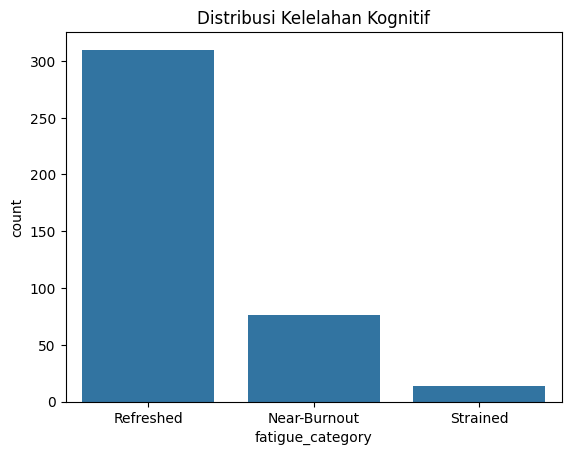

In [ ]:
sns.countplot(data=df_extra, x='fatigue_category')
plt.title("Distribusi Kelelahan Kognitif")
plt.show()

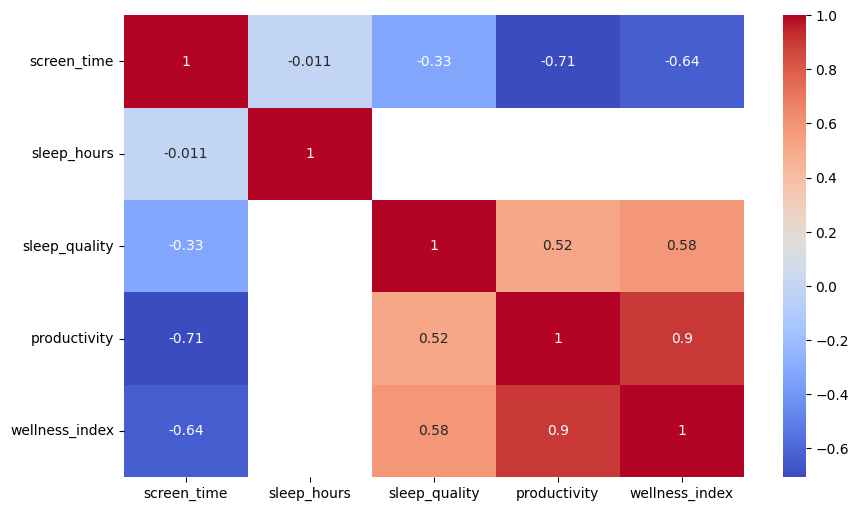

In [ ]:
plt.figure(figsize=(10,6))
numeric_corr = df_combined.select_dtypes(include='number').corr()
sns.heatmap(numeric_corr, annot=True, cmap='coolwarm')
plt.show()

In [ ]:
df_combined.to_csv("cleaned_cognitive_fatigue_dataset.csv", index=False)